In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')
 
plt.style.use('seaborn-v0_8')
print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
nav_df  = pd.read_csv("data/processed/nav_history_cleaned.csv")
fund_df = pd.read_csv("data/processed/fund_master_cleaned.csv")
nav_df["date"] = pd.to_datetime(nav_df["date"])
nav_df = nav_df.sort_values(["amfi_code", "date"])
nav_df["daily_return"] = nav_df.groupby("amfi_code")["nav"].pct_change()
nav_df = nav_df.dropna(subset=["daily_return"])
print("✅ Data loaded")

✅ Data loaded


In [3]:
nav_df["rolling_30d_return"] = nav_df.groupby("amfi_code")["nav"].transform(
    lambda x: x.pct_change(30) * 100
)
print("Rolling 30-day returns calculated")
print(nav_df[["amfi_code","date","nav","rolling_30d_return"]].dropna().head())

Rolling 30-day returns calculated
    amfi_code       date       nav  rolling_30d_return
31     100016 2022-04-08  427.5619          -15.025914
32     100016 2022-04-10  428.3154          -19.381236
33     100016 2022-04-11  452.9791           -4.469696
34     100016 2022-05-01  521.7239           15.276700
35     100016 2022-05-04  531.2213           22.677925


In [4]:
def max_drawdown(nav_series):
    rolling_max = nav_series.cummax()
    drawdown = (nav_series - rolling_max) / rolling_max * 100
    return drawdown.min()
 
drawdown_results = []
for code in nav_df["amfi_code"].unique():
    fund = nav_df[nav_df["amfi_code"] == code].sort_values("date")
    mdd = max_drawdown(fund["nav"])
    name = fund_df[fund_df["amfi_code"] == code]["scheme_name"].values
    if len(name) > 0:
        drawdown_results.append({
            "amfi_code": code,
            "scheme_name": name[0],
            "max_drawdown_pct": round(mdd, 2)
        })
 
drawdown_df = pd.DataFrame(drawdown_results).sort_values("max_drawdown_pct")
print("\n=== Max Drawdown Results ===")
print(drawdown_df)
drawdown_df.to_csv("data/processed/drawdown_results.csv", index=False)
print("✅ Drawdown saved")


=== Max Drawdown Results ===
    amfi_code                                        scheme_name  \
39     149324              DSP Small Cap Fund - Regular - Growth   
30     120843             Kotak Flexicap Fund - Regular - Growth   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
21     119598         SBI Small Cap Fund - Regular Plan - Growth   
38     149323                 DSP Midcap Fund - Regular - Growth   
25     120505           ICICI Pru Midcap Fund - Regular - Growth   
16     119094                Axis Midcap Fund - Regular - Growth   
34     148567      Mirae Asset Large Cap Fund - Regular - Growth   
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth   
19     119551          SBI Bluechip Fund - Regular Plan - Growth   
8      102887              UTI Flexi Cap Fund - Regular - Growth   
3      101206      ABSL Frontline Equity Fund - Regular - Growth   
24     120504          ICICI Pru Bluechip Fund - Direct - Growth   
9      118632     

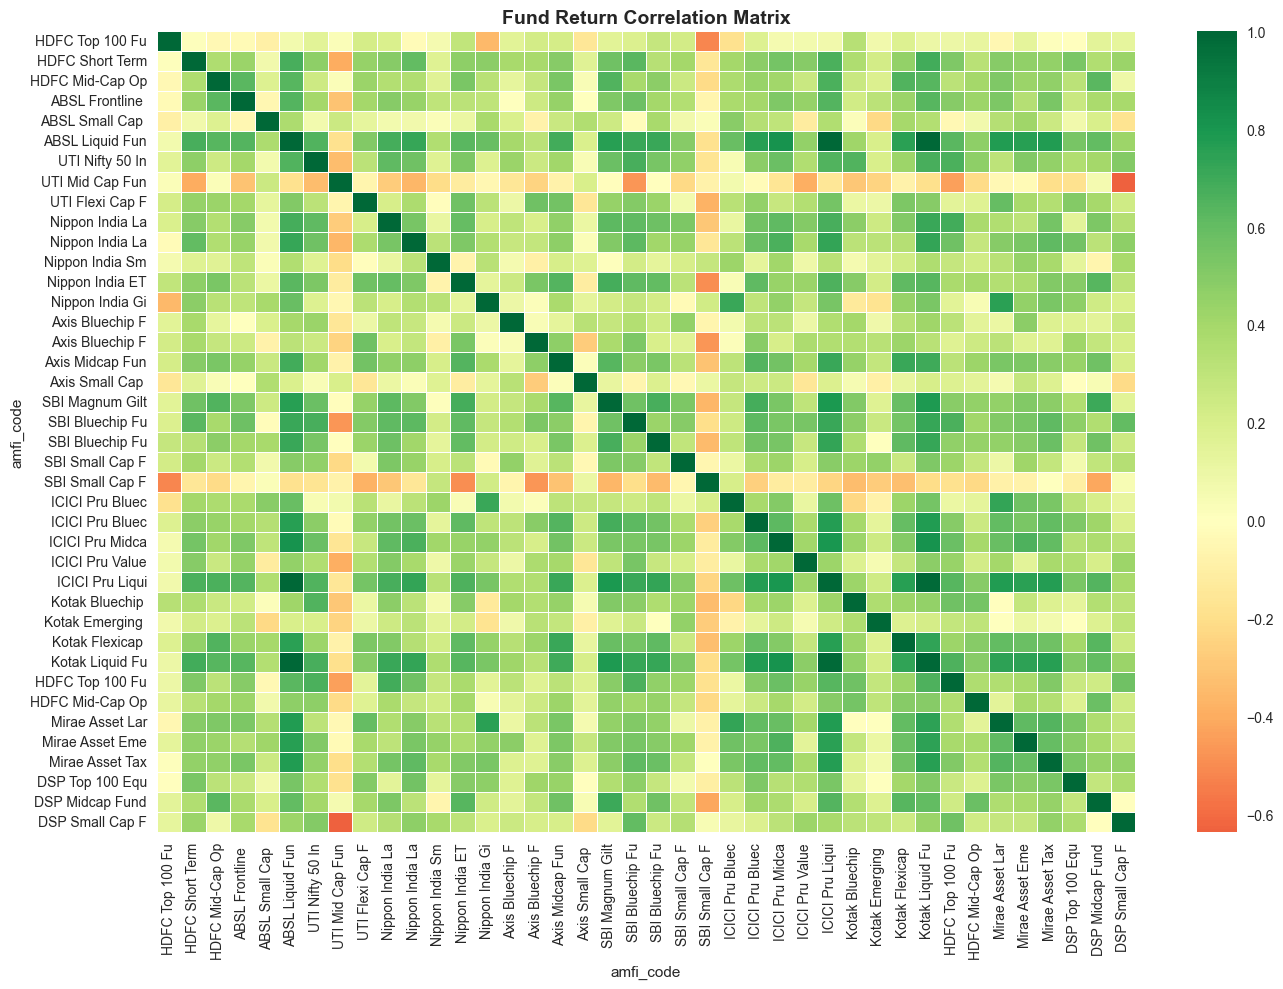

✅ Correlation matrix saved


In [5]:
nav_pivot = nav_df.pivot_table(index="date", columns="amfi_code", values="nav")
nav_pivot = nav_pivot.fillna(method="ffill")
correlation = nav_pivot.pct_change().corr()
 
# Replace amfi_code with short names
short_names = {}
for code in correlation.columns:
    name = fund_df[fund_df["amfi_code"] == code]["scheme_name"].values
    if len(name) > 0:
        short_names[code] = name[0][:15]
correlation = correlation.rename(columns=short_names, index=short_names)
 
plt.figure(figsize=(14, 10))
sns.heatmap(correlation, annot=False, cmap="RdYlGn", center=0,
            linewidths=0.5, fmt=".2f")
plt.title("Fund Return Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/chart10_correlation_matrix.png", dpi=150)
plt.show()
print("✅ Correlation matrix saved")
 

In [6]:
def recommend_funds(risk_profile, fund_df, sharpe_df=None):
    if risk_profile == "Low":
        filtered = fund_df[fund_df["risk_category"].str.contains("Low", na=False)]
    elif risk_profile == "Moderate":
        filtered = fund_df[fund_df["risk_category"].str.contains("Moderate", na=False)]
    else:
        filtered = fund_df[fund_df["risk_category"].str.contains("High", na=False)]
 
    result = filtered[["scheme_name", "fund_house", "category",
                        "expense_ratio_pct", "risk_category"]].head(5)
    return result
 
print("\n=== Recommendations for Low Risk Investor ===")
print(recommend_funds("Low", fund_df))
 
print("\n=== Recommendations for Moderate Risk Investor ===")
print(recommend_funds("Moderate", fund_df))
 
print("\n=== Recommendations for High Risk Investor ===")
print(recommend_funds("High", fund_df))


=== Recommendations for Low Risk Investor ===
                                          scheme_name           fund_house  \
4        SBI Magnum Gilt Fund - Regular Plan - Growth      SBI Mutual Fund   
9        HDFC Short Term Debt Fund - Regular - Growth     HDFC Mutual Fund   
14           ICICI Pru Liquid Fund - Regular - Growth  ICICI Prudential MF   
19  Nippon India Gilt Securities Fund - Regular - ...      Nippon India MF   
23               Kotak Liquid Fund - Regular - Growth    Kotak Mahindra MF   

   category  expense_ratio_pct risk_category  
4      Debt               0.77           Low  
9      Debt               0.56           Low  
14     Debt               0.74           Low  
19     Debt               0.55           Low  
23     Debt               0.60           Low  

=== Recommendations for Moderate Risk Investor ===
                                   scheme_name           fund_house category  \
0    SBI Bluechip Fund - Regular Plan - Growth      SBI Mutual Fund   

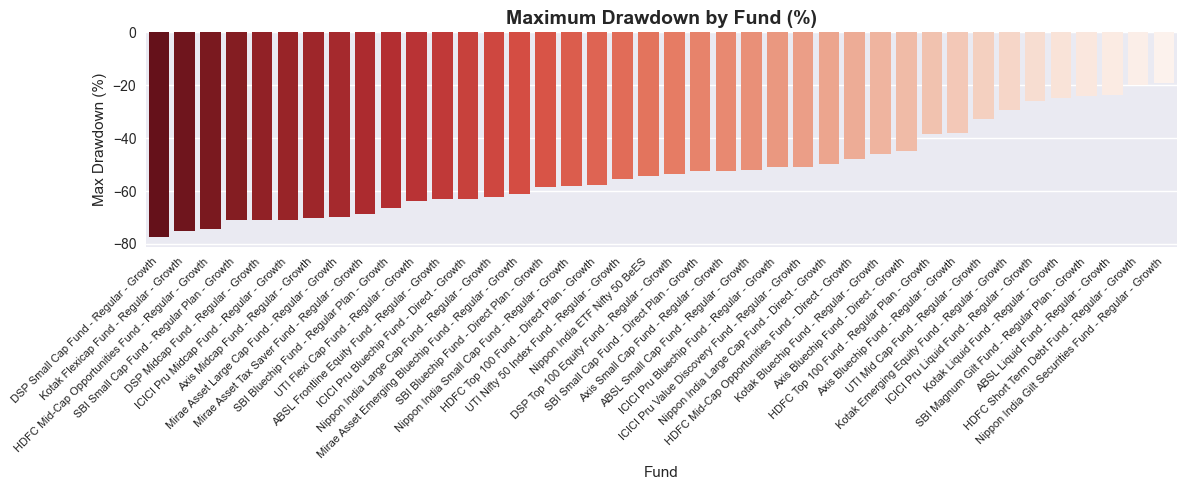

✅ Drawdown chart saved


In [7]:
plt.figure(figsize=(12, 5))
sns.barplot(data=drawdown_df, x="scheme_name", y="max_drawdown_pct", palette="Reds_r")
plt.title("Maximum Drawdown by Fund (%)", fontsize=14, fontweight="bold")
plt.xlabel("Fund")
plt.ylabel("Max Drawdown (%)")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("reports/chart11_max_drawdown.png", dpi=150)
plt.show()
print("✅ Drawdown chart saved")

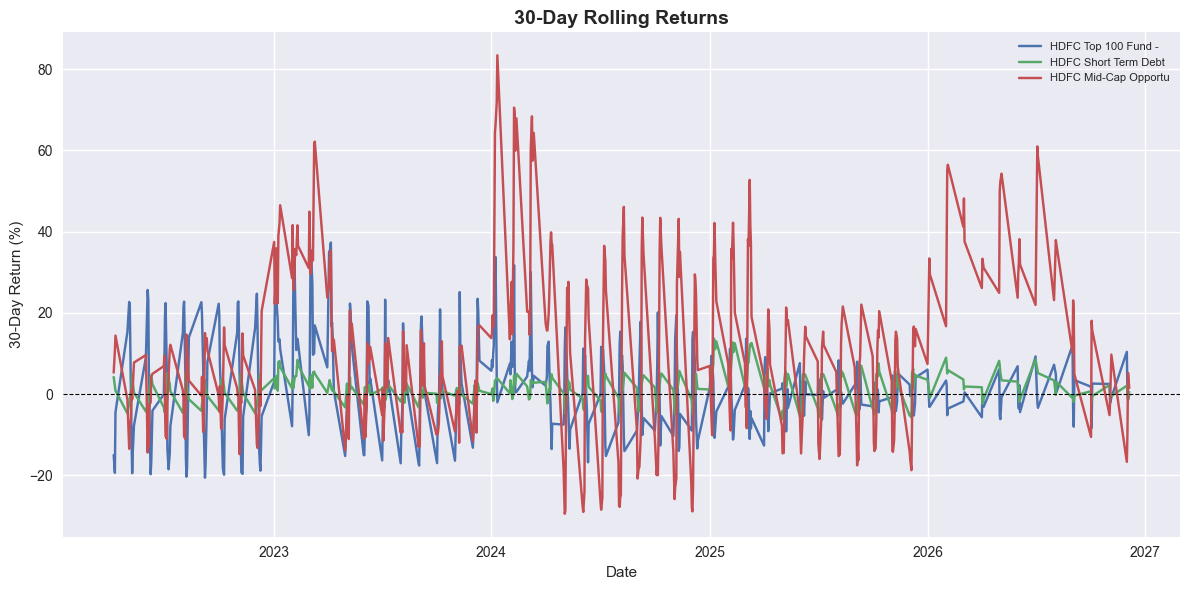

✅ Rolling return chart saved

✅ Day 6 Advanced Analytics Complete!


In [8]:
plt.figure(figsize=(12, 6))
sample_funds = nav_df["amfi_code"].unique()[:3]
for code in sample_funds:
    fund = nav_df[nav_df["amfi_code"] == code].dropna(subset=["rolling_30d_return"])
    name = fund_df[fund_df["amfi_code"] == code]["scheme_name"].values
    label = name[0][:20] if len(name) > 0 else str(code)
    plt.plot(fund["date"], fund["rolling_30d_return"], label=label)
 
plt.title("30-Day Rolling Returns", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("30-Day Return (%)")
plt.legend(fontsize=8)
plt.axhline(y=0, color="black", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig("reports/chart12_rolling_returns.png", dpi=150)
plt.show()
print("✅ Rolling return chart saved")
 
print("\n✅ Day 6 Advanced Analytics Complete!")